In [1]:
# ==========================================
# 1. Create Required Folders
# ==========================================

import os

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

print("Folders created successfully")

Folders created successfully


Dataset Loaded Successfully
Total Images: 628
  Class Name  No of Images
0    Damaged           286
1     Intact           342
Dataset description table saved successfully


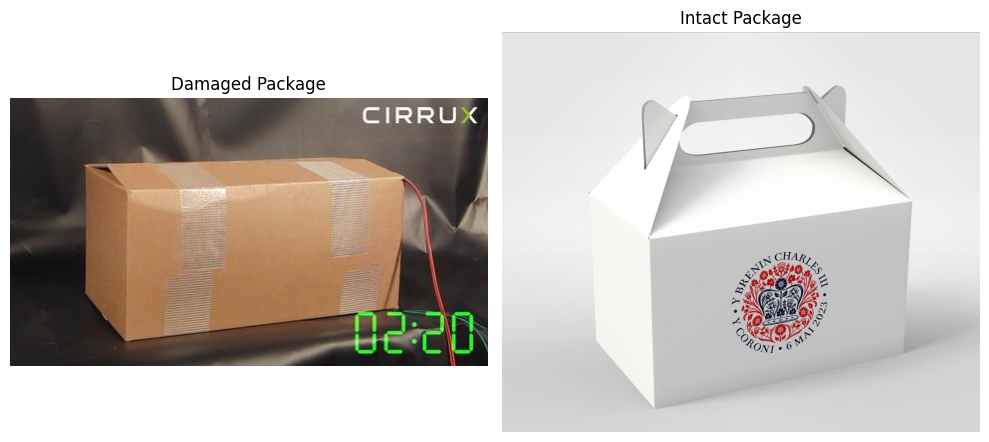

Sample dataset images saved successfully


In [2]:
# ==========================================
# 2. Dataset Loading
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dataset Path
dataset_path = "Downloads/damaged-and-intact-packages"

classes = ['damaged', 'intact']

# Store image paths and labels
image_paths = []
labels = []

# Read dataset
for label, category in enumerate(classes):

    category_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(category_path):

        img_path = os.path.join(category_path, img_name)

        image_paths.append(img_path)
        labels.append(category)

print("Dataset Loaded Successfully")
print("Total Images:", len(image_paths))


# ==========================================
# Dataset Description Table
# ==========================================

damaged_count = len(
    os.listdir(
        os.path.join(dataset_path, 'damaged')
    )
)

intact_count = len(
    os.listdir(
        os.path.join(dataset_path, 'intact')
    )
)

dataset_table = pd.DataFrame({
    "Class Name": ["Damaged", "Intact"],
    "No of Images": [damaged_count, intact_count]
})

print(dataset_table)

dataset_table.to_csv(
    "outputs/tables/dataset_description_table.csv",
    index=False
)

print("Dataset description table saved successfully")


# ==========================================
# Sample Dataset Images Figure
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Damaged sample
damaged_img_path = os.path.join(
    dataset_path,
    "damaged",
    os.listdir(
        os.path.join(dataset_path, "damaged")
    )[0]
)

damaged_img = cv2.imread(damaged_img_path)
damaged_img = cv2.cvtColor(
    damaged_img,
    cv2.COLOR_BGR2RGB
)

axes[0].imshow(damaged_img)
axes[0].set_title("Damaged Package")
axes[0].axis("off")


# Intact sample
intact_img_path = os.path.join(
    dataset_path,
    "intact",
    os.listdir(
        os.path.join(dataset_path, "intact")
    )[0]
)

intact_img = cv2.imread(intact_img_path)
intact_img = cv2.cvtColor(
    intact_img,
    cv2.COLOR_BGR2RGB
)

axes[1].imshow(intact_img)
axes[1].set_title("Intact Package")
axes[1].axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/figures/sample_dataset_images.png",
    bbox_inches='tight'
)

plt.show()

print("Sample dataset images saved successfully")

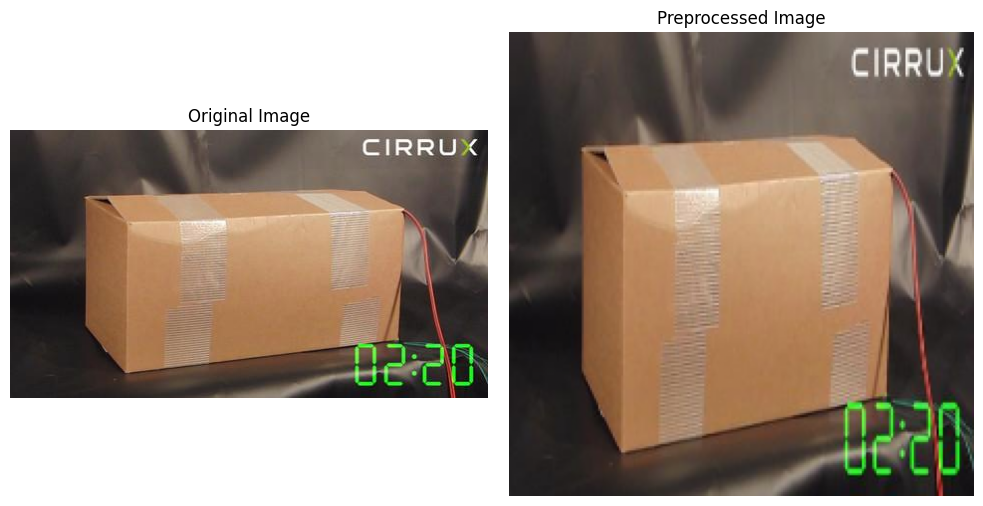

Data preprocessing figure saved successfully


In [3]:
# ==========================================
# 3. DATA PREPROCESSING EXAMPLE
# ==========================================

import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

# Create output folder
os.makedirs("outputs/figures", exist_ok=True)

# Take one sample image
sample_path = os.path.join(
    dataset_path,
    "damaged",
    os.listdir(os.path.join(dataset_path, "damaged"))[0]
)

# Read image
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
resized_img = cv2.resize(img, (224, 224))

# Normalize image
normalized_img = resized_img / 255.0

# Plot preprocessing example
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(normalized_img)
axes[1].set_title("Preprocessed Image")
axes[1].axis("off")

plt.tight_layout()

# Save figure
plt.savefig(
    "outputs/figures/data_preprocessing_example.png",
    bbox_inches='tight'
)

plt.show()

print("Data preprocessing figure saved successfully")

In [4]:
# ==========================================
# 4. IMAGE RESIZING + NORMALIZATION
# ==========================================

import cv2
import numpy as np
import os

IMG_SIZE = 224

X = []
y = []

# Read all images
for label, category in enumerate(classes):

    category_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(category_path):

        img_path = os.path.join(category_path, img_name)

        try:
            # Read image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize image
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalize image
            img = img / 255.0

            # Store image + label
            X.append(img)
            y.append(label)

        except:
            pass

# Convert into NumPy arrays
X = np.array(X)
y = np.array(y)

print("Dataset Loaded Successfully")
print("Image Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Loaded Successfully
Image Shape: (628, 224, 224, 3)
Labels Shape: (628,)


In [21]:
# ==========================================
# 5. TRAIN / VALIDATION / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Create output folders
os.makedirs("outputs/tables", exist_ok=True)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

# ==========================================
# DATASET DESCRIPTION TABLE
# ==========================================

dataset_table = pd.DataFrame({
    "Dataset Split": ["Train", "Validation", "Test"],
    "Number of Images": [
        len(X_train),
        len(X_val),
        len(X_test)
    ]
})

print("\nDataset split Table")
print(dataset_table)

# Save table
dataset_table.to_csv(
    "outputs/tables/dataset_split_table.csv",
    index=False
)

print("\nDataset split table saved successfully")

Train Shape: (439, 224, 224, 3)
Validation Shape: (94, 224, 224, 3)
Test Shape: (95, 224, 224, 3)

Dataset split Table
  Dataset Split  Number of Images
0         Train               439
1    Validation                94
2          Test                95

Dataset split table saved successfully


In [6]:
# ==========================================
# 6. DATA AUGMENTATION
# ==========================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

# Only rescaling for validation & test
test_datagen = ImageDataGenerator()

# Create generators
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

validation_generator = test_datagen.flow(
    X_val,
    y_val,
    batch_size=32,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=32,
    shuffle=False
)

print("Data augmentation completed successfully")
print("Train batches:", len(train_generator))
print("Validation batches:", len(validation_generator))
print("Test batches:", len(test_generator))

Data augmentation completed successfully
Train batches: 14
Validation batches: 3
Test batches: 3


In [7]:
# ==========================================
# 7. CNN MODEL DEVELOPMENT
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Build CNN Model
cnn_model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    MaxPooling2D(2,2),

    # Second Convolution Layer
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(2,2),

    # Third Convolution Layer
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(2,2),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
cnn_model.summary()


# ==========================================
# HYPERPARAMETER TABLE
# ==========================================

import pandas as pd

hyperparameter_table = pd.DataFrame({
    "Hyperparameter": [
        "Image Size",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Loss Function"
    ],
    "Value": [
        "224x224",
        32,
        10,
        "Adam",
        "Binary Crossentropy"
    ]
})

print("\nHyperparameter Table")
print(hyperparameter_table)

# Save table
hyperparameter_table.to_csv(
    "outputs/tables/model_hyperparameter_table.csv",
    index=False
)

print("\nHyperparameter table saved successfully")

/opt/anaconda3/envs/mlproject/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


Hyperparameter Table
  Hyperparameter                Value
0     Image Size              224x224
1     Batch Size                   32
2         Epochs                   10
3      Optimizer                 Adam
4  Loss Function  Binary Crossentropy

Hyperparameter table saved successfully


In [22]:
# ==========================================
# 8.CNN MODEL TRAINING
# ==========================================

EPOCHS = 10

history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32
)

print("CNN Training Completed Successfully")

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - accuracy: 0.8656 - loss: 0.2879 - val_accuracy: 0.7979 - val_loss: 0.5695
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.9043 - loss: 0.2717 - val_accuracy: 0.8085 - val_loss: 0.4465
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.9043 - loss: 0.2450 - val_accuracy: 0.7979 - val_loss: 0.5271
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 0.8793 - loss: 0.2610 - val_accuracy: 0.7766 - val_loss: 0.5868
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - accuracy: 0.9226 - loss: 0.1878 - val_accuracy: 0.7979 - val_loss: 0.5423
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - accuracy: 0.9453 - loss: 0.1481 - val_accuracy: 0.7979 - val_loss: 0.5992
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.9567 - loss: 0.1164 - val_accuracy: 0.7979 - val_loss: 0.6418
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.9681 - loss: 0.0804 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

CNN Performance Metrics Table


,Metric,Value
0,Accuracy,0.757895
1,Precision,0.745763
2,Recall,0.846154
3,F1 Score,0.792793
4,Loss,1.268277


CNN performance table saved successfully


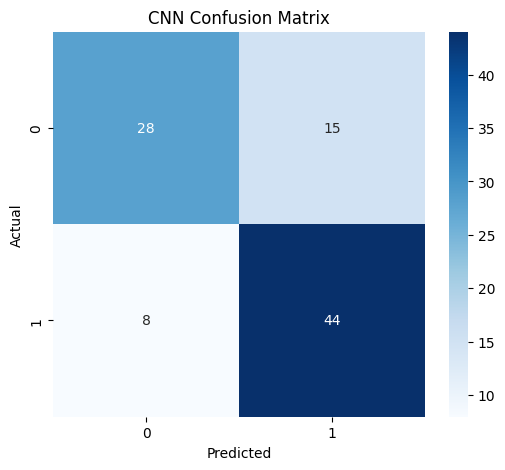

Confusion matrix saved successfully


In [25]:
# ==========================================
# 9. CNN MODEL EVALUATION
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

# ==========================================
# MODEL PREDICTIONS
# ==========================================

y_pred_prob = cnn_model.predict(X_test)

y_pred = (
    y_pred_prob > 0.5
).astype(int).reshape(-1)

# ==========================================
# PERFORMANCE METRICS
# ==========================================

cnn_accuracy = accuracy_score(y_test, y_pred)
cnn_precision = precision_score(y_test, y_pred)
cnn_recall = recall_score(y_test, y_pred)
cnn_f1 = f1_score(y_test, y_pred)

cnn_loss, test_acc = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# ==========================================
# CNN PERFORMANCE TABLE
# ==========================================

cnn_metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Loss"
    ],
    "Value": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        cnn_loss
    ]
})

cnn_metrics_table.to_csv(
    "outputs/tables/cnn_performance_metrics_table.csv",
    index=False
)
print("\nCNN Performance Metrics Table")
display(cnn_metrics_table)

print("CNN performance table saved successfully")

# ==========================================
# 10.CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/figures/confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

print("Confusion matrix saved successfully")

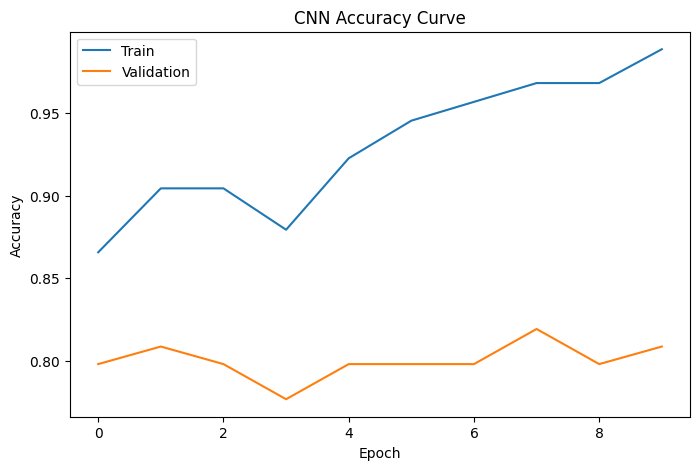

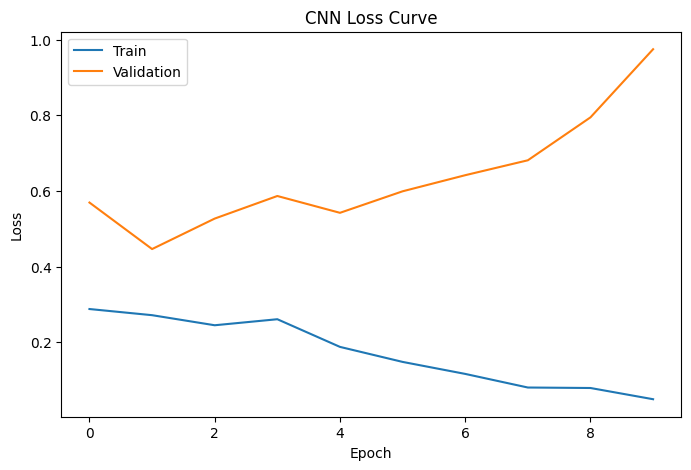

CNN Accuracy/Loss curves saved successfully

Classification Report


,precision,recall,f1-score,support
damaged,0.777778,0.651163,0.708861,43.000000
intact,0.745763,0.846154,0.792793,52.000000
accuracy,0.757895,0.757895,0.757895,0.757895
macro avg,0.761770,0.748658,0.750827,95.000000
weighted avg,0.760254,0.757895,0.754803,95.000000


Classification report saved successfully


In [26]:
# ==========================================
# 11.ACCURACY CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig(
    "outputs/figures/cnn_accuracy_curve.png",
    bbox_inches='tight'
)

plt.show()


# ==========================================
# 11.LOSS CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig(
    "outputs/figures/cnn_loss_curve.png",
    bbox_inches='tight'
)

plt.show()

print("CNN Accuracy/Loss curves saved successfully")

# ==========================================
# 12.CLASSIFICATION REPORT
# ==========================================

report = classification_report(
    y_test,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/tables/classification_report.csv"
)

print("\nClassification Report")
display(report_df)
print("Classification report saved successfully")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.7016 - loss: 0.5985 - val_accuracy: 0.8511 - val_loss: 0.3491
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.8610 - loss: 0.3714 - val_accuracy: 0.8936 - val_loss: 0.3072
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.8565 - loss: 0.3407 - val_accuracy: 0.8723 - val_loss: 0.3076
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8815 - loss: 0.2981 - val_accuracy: 0.8617 - val_loss: 0.3641
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.8793 - loss: 0.2837 - val_accuracy: 0.9043 - val_loss: 0.2902
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9112 - loss: 0.2330 - val_accuracy: 0.9043 - val_loss: 0.2933
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.8907 - loss: 0.2362 - val_accuracy: 0.9043 - val_loss: 0.2830
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.9226 - loss: 0.2019 - val_accuracy: 0.

,Metric,Value
0,Accuracy,0.821053
1,Precision,0.843137
2,Recall,0.826923
3,F1 Score,0.834951
4,Loss,0.330107


MobileNet metrics table saved


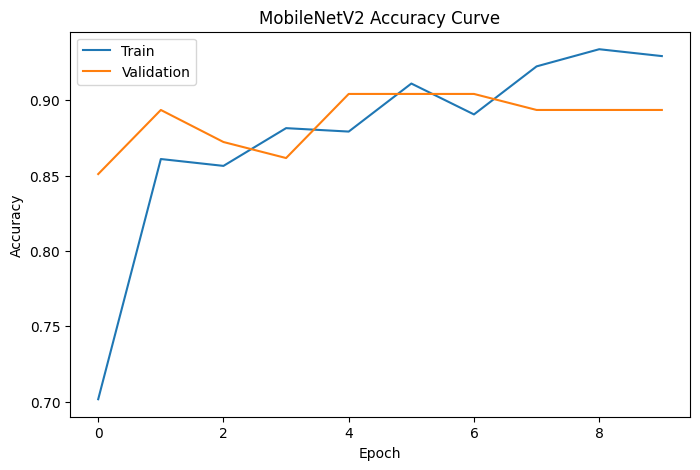

In [27]:
# ==========================================
# 13. MOBILENETV2 TRANSFER LEARNING
# ==========================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================
# BUILD MODEL
# ==========================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


# ==========================================
# TRAIN MODEL
# ==========================================

EPOCHS = 10

mobile_history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

print("MobileNetV2 Training Completed")


# ==========================================
# EVALUATION
# ==========================================

mobile_pred_prob = mobilenet_model.predict(X_test)

mobile_pred = (
    mobile_pred_prob > 0.5
).astype(int).reshape(-1)

mobile_accuracy = accuracy_score(
    y_test,
    mobile_pred
)

mobile_precision = precision_score(
    y_test,
    mobile_pred
)

mobile_recall = recall_score(
    y_test,
    mobile_pred
)

mobile_f1 = f1_score(
    y_test,
    mobile_pred
)

mobile_loss, mobile_acc = mobilenet_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("MobileNet Accuracy:", mobile_accuracy)


# ==========================================
# PERFORMANCE TABLE
# ==========================================

mobilenet_metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Loss"
    ],
    "Value": [
        mobile_accuracy,
        mobile_precision,
        mobile_recall,
        mobile_f1,
        mobile_loss
    ]
})

display(mobilenet_metrics_table)

mobilenet_metrics_table.to_csv(
    "outputs/tables/mobilenet_performance_metrics_table.csv",
    index=False
)

print("MobileNet metrics table saved")


# ==========================================
# ACCURACY CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    mobile_history.history['accuracy']
)

plt.plot(
    mobile_history.history['val_accuracy']
)

plt.title("MobileNetV2 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig(
    "outputs/figures/mobilenet_accuracy_curve.png",
    bbox_inches='tight'
)

plt.show()

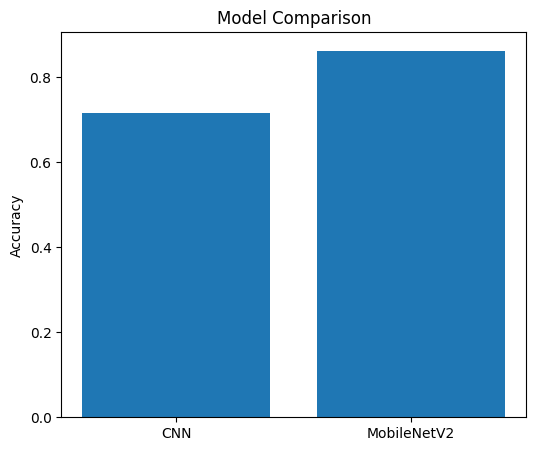

Model comparison chart saved


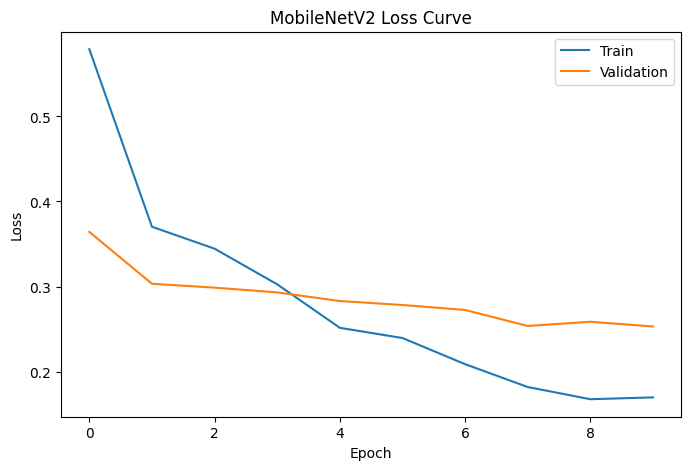

,Model,Accuracy,Loss
0,CNN,0.715789,0.555846
1,MobileNetV2,0.863158,0.339432


Comparison table saved


In [17]:
# ==========================================
# MODEL COMPARISON CHART
# ==========================================

models = [
    "CNN",
    "MobileNetV2"
]

accuracy_scores = [
    cnn_accuracy,
    mobile_accuracy
]

plt.figure(figsize=(6,5))

plt.bar(
    models,
    accuracy_scores
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.savefig(
    "outputs/figures/model_comparison_chart.png",
    bbox_inches='tight'
)

plt.show()

print("Model comparison chart saved")
# ==========================================
# LOSS CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    mobile_history.history['loss']
)

plt.plot(
    mobile_history.history['val_loss']
)

plt.title("MobileNetV2 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.savefig(
    "outputs/figures/mobilenet_loss_curve.png",
    bbox_inches='tight'
)

plt.show()


# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

comparison_table = pd.DataFrame({
    "Model": [
        "CNN",
        "MobileNetV2"
    ],
    "Accuracy": [
        cnn_accuracy,
        mobile_accuracy
    ],
    "Loss": [
        cnn_loss,
        mobile_loss
    ]
})

display(comparison_table)

comparison_table.to_csv(
    "outputs/tables/cnn_vs_mobilenet_comparison_table.csv",
    index=False
)

print("Comparison table saved")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


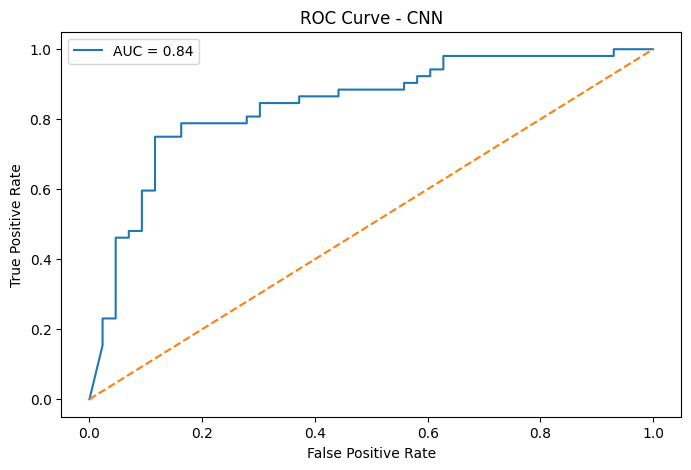

ROC curve saved successfully
Total Wrong Predictions: 23


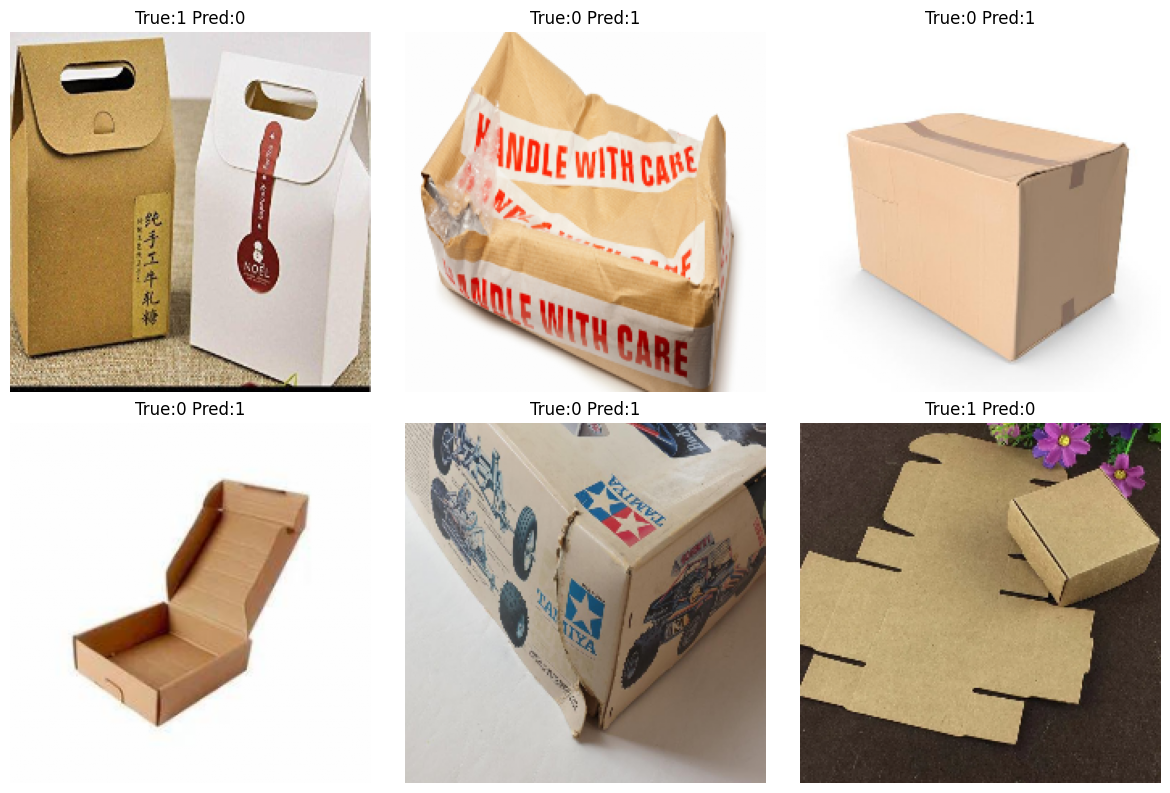

Error analysis figure saved


In [28]:
# ==========================================
#  ADVANCED FEATURES
# ROC + GRAD-CAM + ERROR ANALYSIS
# ==========================================

import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

os.makedirs("outputs/figures", exist_ok=True)

# ==========================================
# 14.ROC CURVE
# ==========================================

y_prob = cnn_model.predict(X_test)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN")

plt.legend()

plt.savefig(
    "outputs/figures/roc_curve.png",
    bbox_inches='tight'
)

plt.show()

print("ROC curve saved successfully")


# ==========================================
# 15.ERROR ANALYSIS
# ==========================================

predictions = (
    y_prob > 0.5
).astype(int).reshape(-1)

wrong_indices = np.where(
    predictions != y_test
)[0]

print("Total Wrong Predictions:",
      len(wrong_indices))

plt.figure(figsize=(12,8))

for i, idx in enumerate(
    wrong_indices[:6]
):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True:{y_test[idx]} "
        f"Pred:{predictions[idx]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/figures/error_analysis.png",
    bbox_inches='tight'
)

plt.show()

print("Error analysis figure saved")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Using Layer: conv2d_2


/opt/anaconda3/envs/mlproject/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


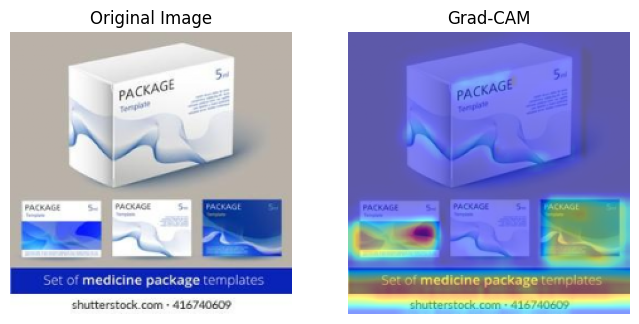

Grad-CAM saved successfully
Models saved successfully

Figures Folder:
['confusion_matrix.png', 'data_preprocessing_example.png', 'mobilenet_loss_curve.png', 'cnn_loss_curve.png', 'sample_dataset_images.png', 'gradcam_visualization.png', 'cnn_architecture.png', 'error_analysis.png', 'cnn_accuracy_curve.png', 'mobilenet_accuracy_curve.png', 'roc_curve.png', '.ipynb_checkpoints', 'model_comparison_chart.png']

Tables Folder:
['dataset_split_table.csv', 'classification_report.csv', 'cnn_performance_metrics_table.csv', 'mobilenet_performance_metrics_table.csv', 'dataset_description_table.csv', 'model_hyperparameter_table.csv', '.ipynb_checkpoints', 'cnn_vs_mobilenet_comparison_table.csv']

Saved Models:
['mobilenet_model.h5', 'cnn_model.h5']


In [29]:
# ==========================================
# 16.GRAD-CAM VISUALIZATION
# ==========================================

img = X_test[0]

img_array = np.expand_dims(
    img,
    axis=0
)

# Build model
_ = cnn_model.predict(img_array)

# Find last conv layer
last_conv_layer = None

for layer in reversed(cnn_model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer = layer
        break

print("Using Layer:",
      last_conv_layer.name)

grad_model = tf.keras.models.Model(
    inputs=cnn_model.inputs,
    outputs=[
        last_conv_layer.output,
        cnn_model.outputs[0]
    ]
)

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        img_array
    )

    loss = predictions[:,0]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(heatmap)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(
    heatmap,
    cmap='jet',
    alpha=0.5
)

plt.title("Grad-CAM")
plt.axis("off")

plt.savefig(
    "outputs/figures/gradcam_visualization.png",
    bbox_inches='tight'
)

plt.show()

print("Grad-CAM saved successfully")


# ==========================================
# SAVE MODELS
# ==========================================

cnn_model.save(
    "saved_models/cnn_model.h5"
)

mobilenet_model.save(
    "saved_models/mobilenet_model.h5"
)

print("Models saved successfully")


# ==========================================
# FINAL FILE CHECK
# ==========================================

print("\nFigures Folder:")
print(os.listdir("outputs/figures"))

print("\nTables Folder:")
print(os.listdir("outputs/tables"))

print("\nSaved Models:")
print(os.listdir("saved_models"))